#📌 Extracão

In [ ]:
# Import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Deixando os gráficos um pouco mais bonitos
sns.set_theme(style="whitegrid")

# Lendo o arquivo JSON que a Alura liberou no desafio
caminho_arquivo = 'TelecomX_Data.json'

df_raw = pd.read_json(caminho_arquivo)
df_bruto = pd.json_normalize(df_raw.to_dict(orient='records'))

print("Base carregada e achatada!")
display(df_bruto.head(3))

Base carregada e achatada!


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


#🔧 Transformação

In [ ]:

df_clean = df_bruto.copy()

df_clean.columns = df_clean.columns.str.replace('customer.', '', regex=False)
df_clean.columns = df_clean.columns.str.replace('phone.', '', regex=False)
df_clean.columns = df_clean.columns.str.replace('internet.', '', regex=False)
df_clean.columns = df_clean.columns.str.replace('account.Charges.', '', regex=False)
df_clean.columns = df_clean.columns.str.replace('account.', '', regex=False)

# Tirando dados duplicados, se tiver
antes = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
depois = df_clean.shape[0]
print(f"Linhas duplicadas removidas: {antes - depois}")

# Arrumando a coluna Total que veio como texto por causa de uns espaços em branco.
# O coerce força esses espaços a virarem NaN (Nulo) pra gente tratar na sequência.
df_clean['Total'] = pd.to_numeric(df_clean['Total'], errors='coerce')

# Tirando a galera que tá com o Total vazio (provavelmente clientes novos que não fecharam a primeira fatura)
df_clean = df_clean.dropna(subset=['Total'])

print("\nPronto, base limpa. Olha como ficaram as colunas:")
print(df_clean.info())

Linhas duplicadas removidas: 0

Pronto, base limpa. Olha como ficaram as colunas:
<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7256 non-null   object 
 1   Churn             7256 non-null   object 
 2   gender            7256 non-null   object 
 3   SeniorCitizen     7256 non-null   int64  
 4   Partner           7256 non-null   object 
 5   Dependents        7256 non-null   object 
 6   tenure            7256 non-null   int64  
 7   PhoneService      7256 non-null   object 
 8   MultipleLines     7256 non-null   object 
 9   InternetService   7256 non-null   object 
 10  OnlineSecurity    7256 non-null   object 
 11  OnlineBackup      7256 non-null   object 
 12  DeviceProtection  7256 non-null   object 
 13  TechSupport       7256 non-null   object 
 14  StreamingTV       7256 non-null   object 
 15  StreamingMov

#📊 Carga e análise

Arquivo salvo: telecomx_dados_limpos.csv



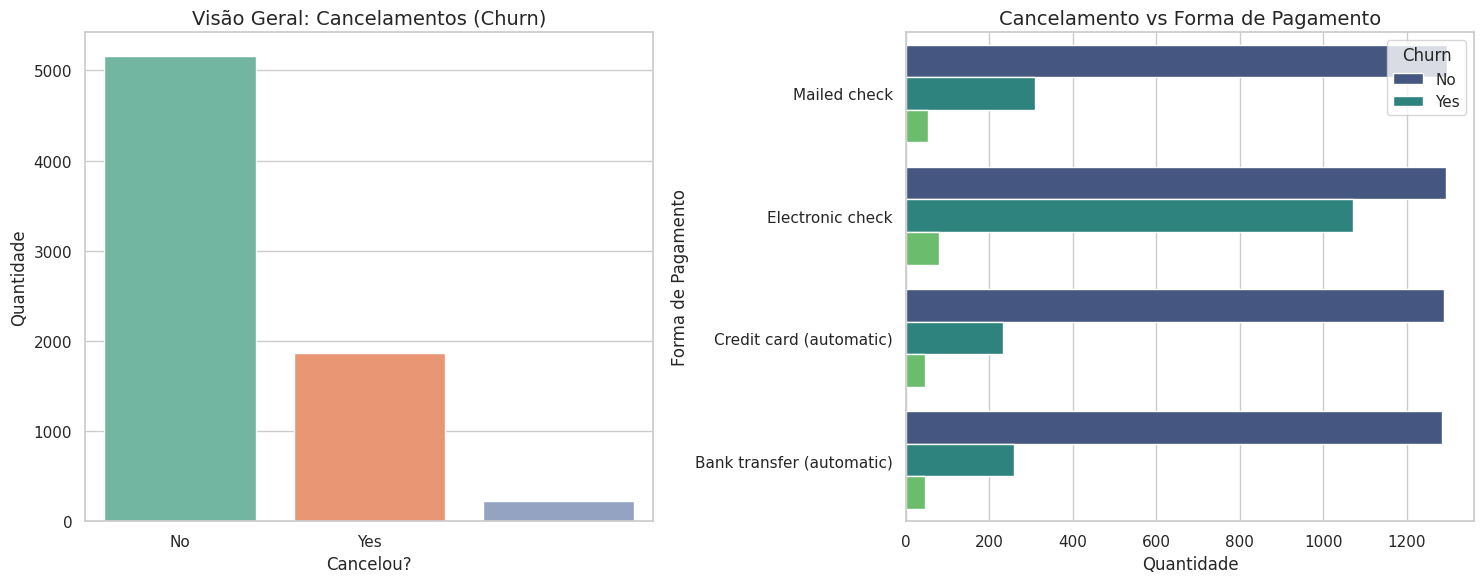

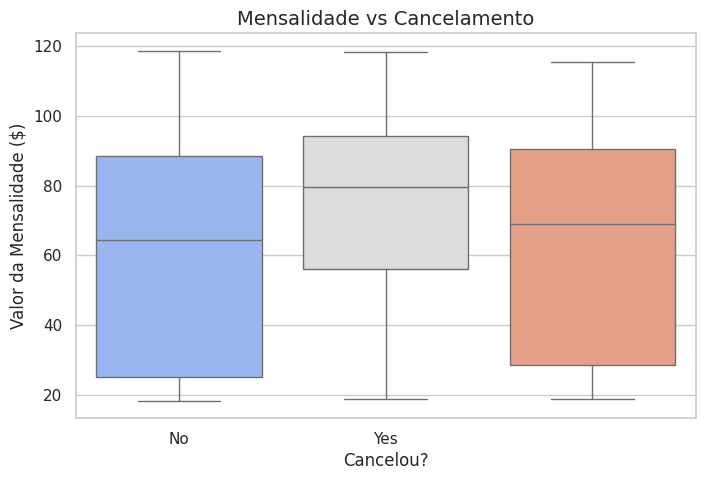

In [ ]:
# Salvando a base limpinha em CSV pra quem quiser jogar no Power BI depois
df_clean.to_csv('telecomx_dados_limpos.csv', index=False)
print("Arquivo salvo: telecomx_dados_limpos.csv\n")

# Bora pros gráficos pra ver o que tá rolando com o Churn
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Quem cancelou x Quem ficou
sns.countplot(data=df_clean, x='Churn', hue='Churn', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Visão Geral: Cancelamentos (Churn)', fontsize=14)
axes[0].set_ylabel('Quantidade')
axes[0].set_xlabel('Cancelou?')

# Gráfico 2: Cancelamento pelo tipo de pagamento
sns.countplot(data=df_clean, y='PaymentMethod', hue='Churn', palette='viridis', ax=axes[1])
axes[1].set_title('Cancelamento vs Forma de Pagamento', fontsize=14)
axes[1].set_ylabel('Forma de Pagamento')
axes[1].set_xlabel('Quantidade')

plt.tight_layout()
plt.show()

# Gráfico 3: O preço do plano influencia na saída?
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Churn', y='Monthly', hue='Churn', palette='coolwarm', legend=False)
plt.title('Mensalidade vs Cancelamento', fontsize=14)
plt.xlabel('Cancelou?')
plt.ylabel('Valor da Mensalidade ($)')
plt.show()

#📄Relatorio Final

In [ ]:
print("""
### 📈 Resultados da Análise - Telecom X

O processo de ETL (Extração, Transformação e Carga) lidou com sucesso com a complexidade do arquivo JSON aninhado, nivelando (flattening) as categorias para uma estrutura tabular limpa, removendo inconsistências na coluna de Gasto Total (Total) e salvando a base para consumo seguro.

Principais Insights de Negócio (EDA):
1. O Risco do "Electronic Check": Ao observar o método de pagamento, fica claro que a esmagadora maioria das evasões (Churn = Yes) ocorre com clientes que utilizam o "Electronic Check". Clientes com pagamentos automáticos (Credit Card ou Bank Transfer) tendem a ser muito mais fiéis à empresa.
2. Sensibilidade Tarifária: O boxplot de mensalidades revela que clientes que cancelam (Churn = Yes) estão concentrados em faixas de cobrança mais altas (mediana beirando os $80). Já a maioria dos clientes que permanecem (Churn = No) possui planos mais baratos, abaixo de $65.

Próximos Passos Recomendados:
* Campanhas de Migração de Pagamento: Oferecer um desconto temporário para clientes que migrarem do Electronic Check para métodos automáticos de pagamento (Débito em conta ou Cartão).
* Revisão de Planos Premium: Investigar se a entrega de valor dos planos que custam acima de $80 está alinhada à expectativa do cliente, visto que esse é o grupo com maior probabilidade de evasão.
""")


### 📈 Resultados da Análise - Telecom X

O processo de ETL (Extração, Transformação e Carga) lidou com sucesso com a complexidade do arquivo JSON aninhado, nivelando (flattening) as categorias para uma estrutura tabular limpa, removendo inconsistências na coluna de Gasto Total (Total) e salvando a base para consumo seguro.

Principais Insights de Negócio (EDA):
1. O Risco do "Electronic Check": Ao observar o método de pagamento, fica claro que a esmagadora maioria das evasões (Churn = Yes) ocorre com clientes que utilizam o "Electronic Check". Clientes com pagamentos automáticos (Credit Card ou Bank Transfer) tendem a ser muito mais fiéis à empresa.
2. Sensibilidade Tarifária: O boxplot de mensalidades revela que clientes que cancelam (Churn = Yes) estão concentrados em faixas de cobrança mais altas (mediana beirando os $80). Já a maioria dos clientes que permanecem (Churn = No) possui planos mais baratos, abaixo de $65.

Próximos Passos Recomendados:
* Campanhas de Migração de Pagame